In [92]:
from matplotlib import axis
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [93]:
import os
import numpy as np
import pylab as plt
import networkx as nx
from sklearn.neighbors import kneighbors_graph
from sklearn.metrics import pairwise_distances
from modules import MDSTorusProjector, apsp_distance_matrix, plot_embedding_with_torus_edges
import umap
import cmocean
from modules.initialization import find_fundamental_torus_directions, torus_init_from_eigenpairs, _torus_geom_from_result
from modules.metrics import rect_torus_stress
from pathlib import Path


In [94]:
FINALIZE_MODE = "none" # "none" or "lbfgs"

In [95]:
# data_path = "/gpfs01/berens/user/sdamrich/data/graph_torus/3figures"
data_path = "./3figures"
assert Path(data_path).exists()
pca = np.load(os.path.join(data_path, "yoda_bulldog_pca50.npy"))
phases = np.load(os.path.join(data_path, "phases.npy"))
print(pca.shape, phases.shape)
cmap = cmocean.cm.phase

(8100, 50) (8100, 2)


In [97]:
# helpers
def circ_align(u, theta):
    """|circular alignment| between a torus coordinate u in [0, 1) and an angle theta in [0, 2pi),
    invariant to global offset and orientation. Output in [0, 1]"""
    zu = np.exp(2j * np.pi * np.asarray(u))
    zt = np.exp(1j * np.asarray(theta))
    return max(abs(np.mean(zu * np.conj(zt))), abs(np.mean(zu * zt)))


def report_recovery(X, phases, label):
    for ax_i in range(2):
        print(f"{label}, axis {ax_i}: circ_align yoda {circ_align(X[:, ax_i], phases[:, 0]):.3f}, "
              f"bulldog {circ_align(X[:, ax_i], phases[:, 1]):.3f}")

In [98]:
# subsampled data

## nothing but PCA really works on the subsampled data bc the kNN graph is of poor quality

In [99]:
m = 1000
#submsample = np.arange(m, dtype=int)

seed = 0
np.random.seed(seed)
subsample = np.argpartition(np.random.randn(len(pca)), m)[:m]

len(subsample)

1000

In [100]:
## knn graph

In [101]:
k = 15
A = kneighbors_graph(pca[subsample, :5], n_neighbors=k, mode='connectivity', include_self=False)
A = A.maximum(A.T)  # symmetrize: union of directed edges, keeps values in {0, 1}
G = nx.from_scipy_sparse_array(A)
print(f"{G.number_of_nodes()} nodes, {G.number_of_edges()} edges, connected: {nx.is_connected(G)}")

1000 nodes, 8878 edges, connected: True


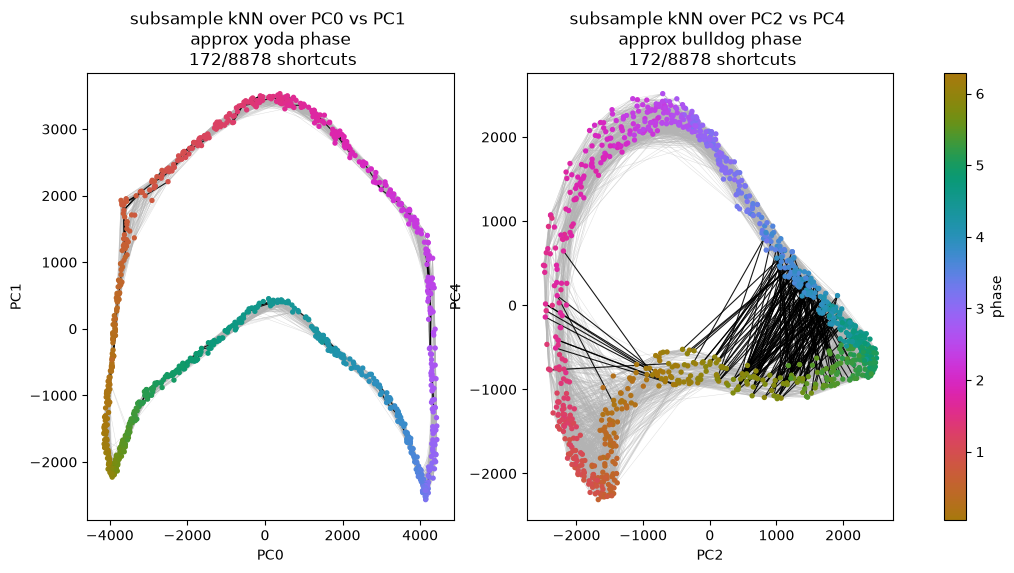

In [102]:
# subsample kNN graph edges over two PCA projections;
# shortcut edges (endpoints >45 deg apart on the true torus) highlighted in red
from matplotlib.collections import LineCollection
SHORTCUT_DEG = 90   # a "neighbor" >90 deg away on the true torus is a false edge (note that this is not degree in one direciton, but overall distances in 2pi * 2pi torus embedding via phase coordinates


Acoo = A.tocoo()
e = Acoo.row < Acoo.col                 # each undirected edge once
ei, ej = Acoo.row[e], Acoo.col[e]
P = pca[subsample]; ph = phases[subsample]
d = (ph[ej] - ph[ei] + np.pi) % (2 * np.pi) - np.pi      # per-axis min-image angle delta
short = np.degrees(np.hypot(d[:, 0], d[:, 1])) > SHORTCUT_DEG       # shortcut = far apart on true torus

fig, axes = plt.subplots(1, 2, figsize=(13, 5.8))
for i, (ax, (d0, d1), phase_name) in enumerate(zip(axes, [(0, 1), (2, 4)], ["yoda", "bulldog"])):
    segs = np.stack([P[ei][:, [d0, d1]], P[ej][:, [d0, d1]]], axis=1)
    ax.add_collection(LineCollection(segs[~short], colors="0.7", linewidths=0.3, alpha=0.5))
    ax.add_collection(LineCollection(segs[short],  colors="k", linewidths=0.8, alpha=0.9, zorder=2))
    sc = ax.scatter(P[:, d0], P[:, d1], c=ph[:, i], cmap=cmocean.cm.phase, s=8, zorder=3)
    ax.set_xlabel(f"PC{d0}"); ax.set_ylabel(f"PC{d1}")
    ax.set_title(f"subsample kNN over PC{d0} vs PC{d1} \n approx {phase_name} phase \n {short.sum()}/{len(short)} shortcuts")
    ax.autoscale()
fig.colorbar(sc, ax=axes, label="phase")   # ph[:, 0] for yoda
plt.show()

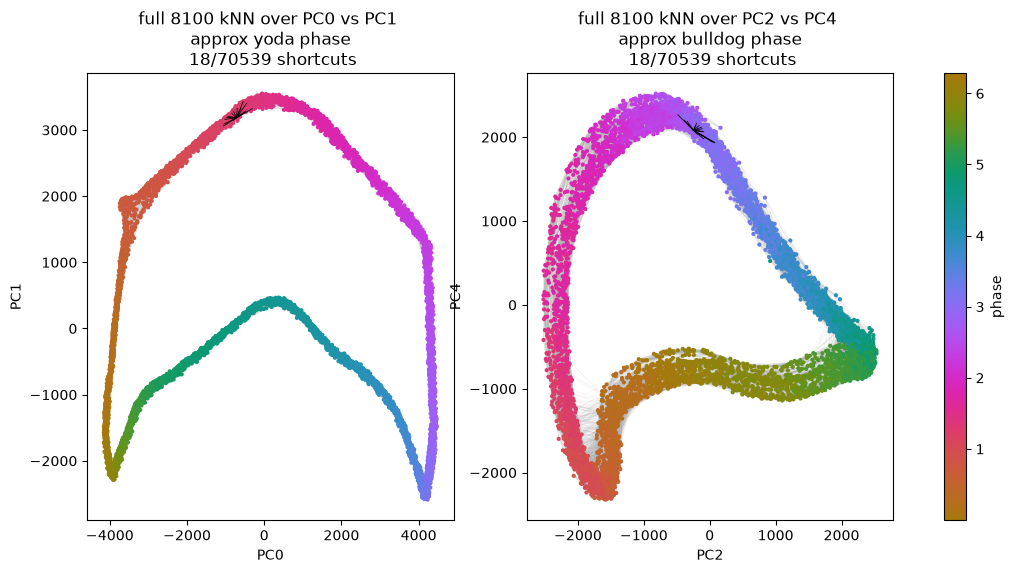

In [103]:
# same view for the FULL (non-subsampled) kNN graph over the full PCA
from matplotlib.collections import LineCollection

A_full = kneighbors_graph(pca[:, :5], n_neighbors=k, mode='connectivity', include_self=False)
A_full = A_full.maximum(A_full.T).tocoo()
ef = A_full.row < A_full.col                 # each undirected edge once
fi, fj = A_full.row[ef], A_full.col[ef]
d = (phases[fj] - phases[fi] + np.pi) % (2 * np.pi) - np.pi
short = np.degrees(np.hypot(d[:, 0], d[:, 1])) > SHORTCUT_DEG

fig, axes = plt.subplots(1, 2, figsize=(13, 5.8))
for i, (ax, (d0, d1), phase_name) in enumerate(zip(axes, [(0, 1), (2, 4)], ["yoda", "bulldog"])):
    segs = np.stack([pca[fi][:, [d0, d1]], pca[fj][:, [d0, d1]]], axis=1)
    ax.add_collection(LineCollection(segs[~short], colors="0.7", linewidths=0.2, alpha=0.3))
    ax.add_collection(LineCollection(segs[short],  colors="k", linewidths=0.6, alpha=0.9, zorder=5))
    sc = ax.scatter(pca[:, d0], pca[:, d1], c=phases[:, i], cmap=cmocean.cm.phase, s=4, zorder=3)
    ax.set_xlabel(f"PC{d0}"); ax.set_ylabel(f"PC{d1}")
    ax.set_title(f"full 8100 kNN over PC{d0} vs PC{d1} \n approx {phase_name} phase \n {short.sum()}/{len(short)} shortcuts")
    ax.autoscale()
fig.colorbar(sc, ax=axes, label="phase")
# --> probably one point in the full sample is mispositioned


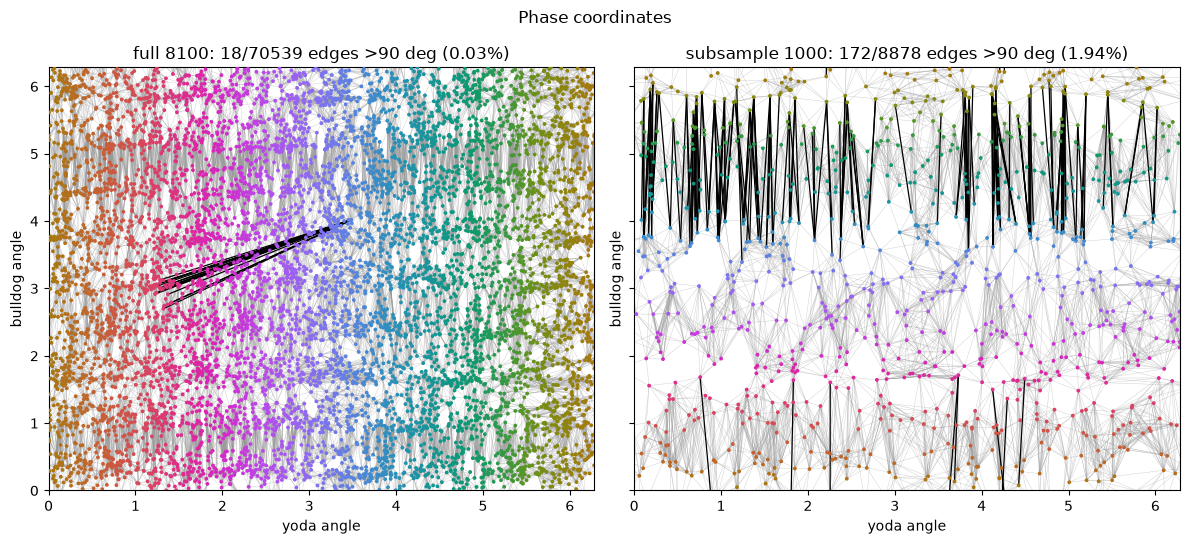

In [104]:
# CONFIRMATION 1: draw each kNN edge in true (yoda, bulldog) angle space.
# faithful edge = tiny segment (local mesh); shortcut = long red segment across the torus.
from sklearn.neighbors import kneighbors_graph
from matplotlib.collections import LineCollection

def graph_segments(feat, ph, k=15):
    A = kneighbors_graph(feat, k, mode='connectivity', include_self=False)
    A = A.maximum(A.T).tocoo()
    e = A.row < A.col                                  # each undirected edge once
    i, j = A.row[e], A.col[e]
    d = (ph[j] - ph[i] + np.pi) % (2 * np.pi) - np.pi  # min-image signed delta per axis
    segs = np.stack([ph[i], ph[i] + d], axis=1)        # segment i -> i + min-image(delta)
    length = np.degrees(np.hypot(d[:, 0], d[:, 1]))    # true edge length in degrees
    return segs, length

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5), sharex=True, sharey=True)
for i, (ax, (tag, idx)) in enumerate(zip(axes, [("full 8100", np.arange(len(pca))), ("subsample 1000", subsample)])):
    segs, length = graph_segments(pca[idx, :5], phases[idx], k)
    short = length > SHORTCUT_DEG                   # true edge length in degrees
    ax.add_collection(LineCollection(segs[~short], colors="0.6", linewidths=0.3, alpha=0.5))
    if short.any():
        ax.add_collection(LineCollection(segs[short], colors="k", linewidths=0.9))
    ax.scatter(*phases[idx].T, s=3, c=phases[idx, i], cmap=cmocean.cm.phase, zorder=3)
    ax.set(xlim=(0, 2*np.pi), ylim=(0, 2*np.pi), xlabel="yoda angle", ylabel="bulldog angle")
    ax.set_title(f"{tag}: {short.sum()}/{len(length)} edges >{SHORTCUT_DEG} deg ({100*short.mean():.2f}%)")
fig.suptitle("Phase coordinates")
plt.tight_layout(); plt.show()
# --> probably one point in the full sample is mispositioned

In [105]:
D, nodes = apsp_distance_matrix(G)
print(D.shape)

(1000, 1000)


In [106]:
proj = MDSTorusProjector()
X = proj.fit_transform(D/D.max(), learn_mode='rectangular', r0_init=1.5, r1_init=1, finalize=FINALIZE_MODE)

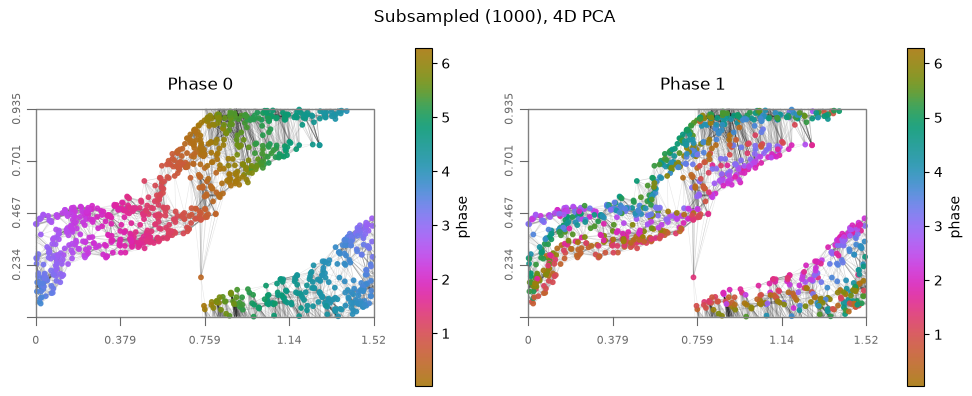

In [107]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for i, ax in enumerate(axes):
    plot_embedding_with_torus_edges(X=X, G=G, torus=proj, colors=phases[subsample, i], cmap=cmap, ax=ax)
    ax.set_title(f"Phase {i}")
    plt.colorbar(ax.collections[-1], ax=ax, label="phase")

plt.suptitle("Subsampled (1000), 4D PCA")
plt.tight_layout()
plt.show()

In [108]:
spec_1k = find_fundamental_torus_directions(D/D.max())
fund_1k = spec_1k["fundamental_directions"]
init_spectral_1k = torus_init_from_eigenpairs(fund_1k[0]["eigenvectors"], fund_1k[1]["eigenvectors"])
print(f"estimated aspect ratio: {spec_1k['aspect_ratio']:.2f}")

estimated aspect ratio: 1.97


spectral init, axis 0: circ_align yoda 0.991, bulldog 0.025
spectral init, axis 1: circ_align yoda 0.097, bulldog 0.795


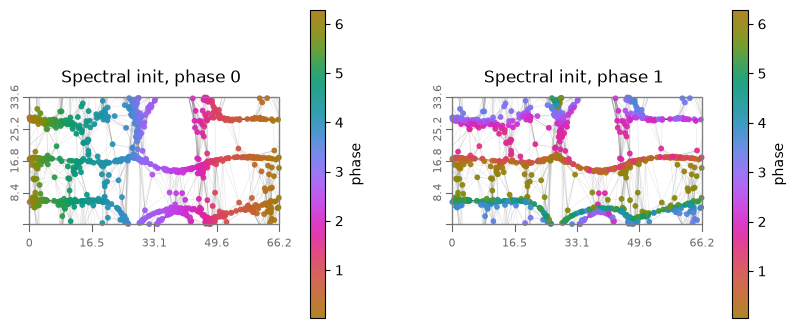

In [109]:
report_recovery(init_spectral_1k, phases[subsample], "spectral init")
# expected: one axis ~0.98 vs yoda, the other ~0.96 vs bulldog

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for i, ax in enumerate(axes):
    plot_embedding_with_torus_edges(X=init_spectral_1k, G=G, torus= _torus_geom_from_result(spec_1k), colors=phases[subsample, i], cmap=cmap, ax=ax)
    ax.set_title(f"Spectral init, phase {i}")
    plt.colorbar(ax.collections[-1], ax=ax, label="phase")


plt.show()

SGD from spectral init, axis 0: circ_align yoda 0.991, bulldog 0.020
SGD from spectral init, axis 1: circ_align yoda 0.053, bulldog 0.875


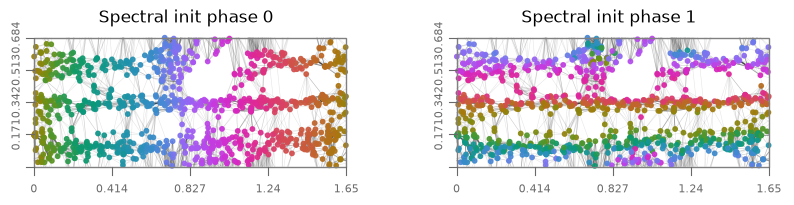

In [110]:
proj_spec = MDSTorusProjector()
X_spec_1k = proj_spec.fit_transform(D/D.max(), learn_mode='rectangular', init=spec_1k, finalize=FINALIZE_MODE)  # aspect ratio and side lengths are inferred from the spec dict
report_recovery(X_spec_1k, phases[subsample], "SGD from spectral init")
# With init, learning_rate='auto' uses the init-preserving schedule: first tail step 0.1, no warmup.
# with 4096 pairs per epoch each point receives ~8 updates per epoch (vs ~1 at n=8100),
# so the unstable default step scrambles the init much harder (0.47-0.89 across seeds at
# the default vs ~0.88 consistently at 0.1, tested with landmark distances + good init).
# the remaining limit here is the subsample-only graph itself, see the landmark section
# at the end of the notebook.

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for i, ax in enumerate(axes):
    plot_embedding_with_torus_edges(X=X_spec_1k, G=G, torus=proj_spec, colors=phases[subsample, i], cmap=cmap, ax=ax)
    ax.set_title(f"Spectral init phase {i}")
plt.show()

subsample-graph D + GT init, axis 0: circ_align yoda 0.964, bulldog 0.024
subsample-graph D + GT init, axis 1: circ_align yoda 0.551, bulldog 0.401


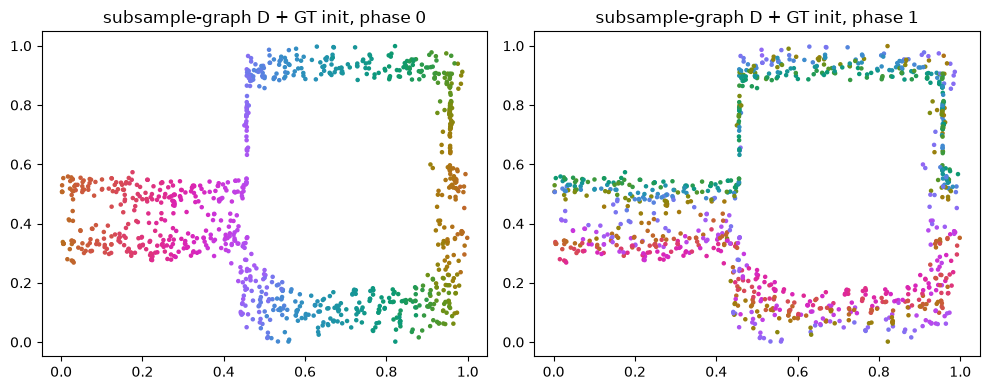

In [111]:
# subsample-graph geodesics + ground-truth init (isolates graph quality from init quality)
init_gt_sub = phases[subsample] / (2 * np.pi)
proj_test = MDSTorusProjector()
X_test = proj_test.fit_transform(D / D.max(), learn_mode='rectangular',
                                 r0_init=0.5, r1_init=0.5, init=init_gt_sub, finalize=FINALIZE_MODE)
report_recovery(X_test, phases[subsample], "subsample-graph D + GT init")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for i, ax in enumerate(axes):
    ax.scatter(*X_test.T, c=cmap(phases[subsample, i] / (2 * np.pi)), s=5)
    ax.set_title(f"subsample-graph D + GT init, phase {i}")
plt.tight_layout(); plt.show()

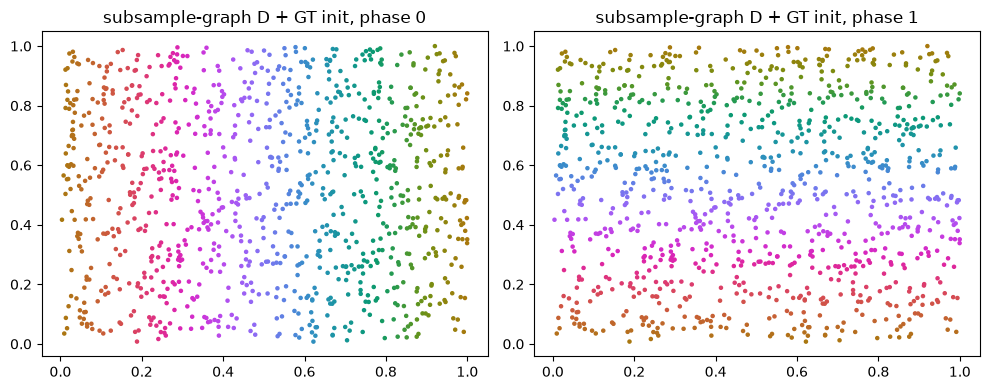

In [112]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for i, ax in enumerate(axes):
    ax.scatter(*init_gt_sub.T, c=cmap(phases[subsample, i] / (2 * np.pi)), s=5)
    ax.set_title(f"subsample-graph D + GT init, phase {i}")
plt.tight_layout(); plt.show()

/home/wsl/.virtualenvs/Torus-mds/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/wsl/.virtualenvs/Torus-mds/lib/python3.12/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/home/wsl/.virtualenvs/Torus-mds/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


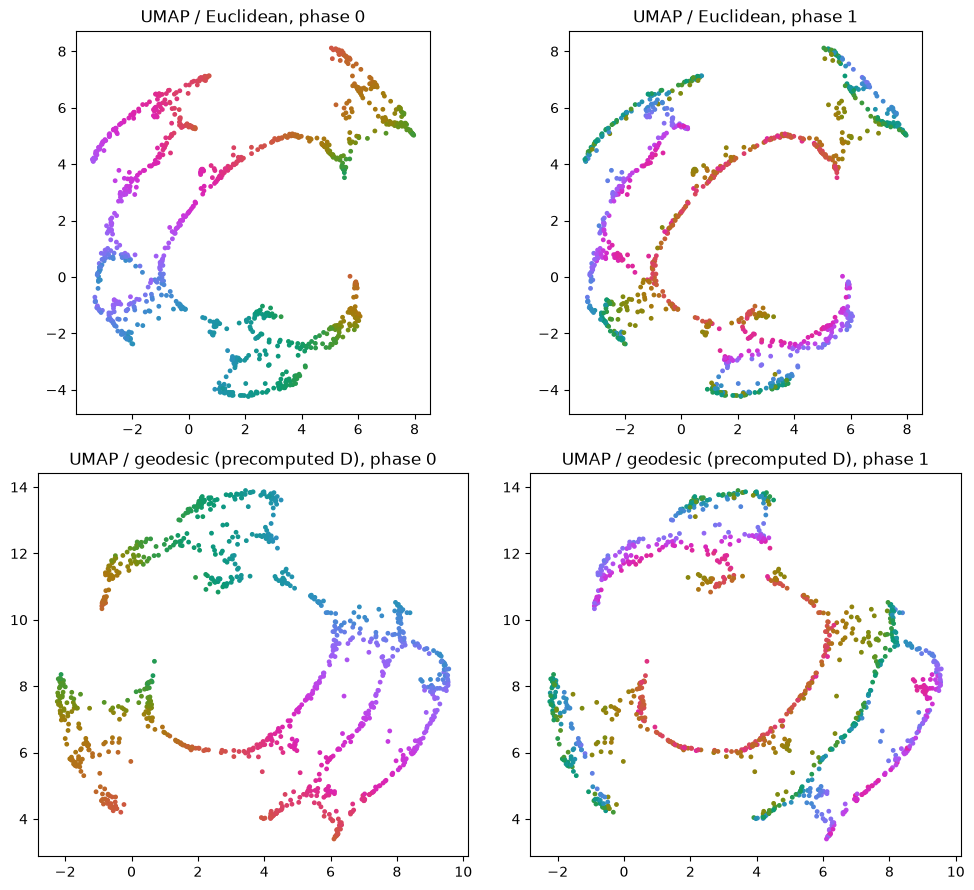

In [113]:
# probe: UMAP on the same subsample, Euclidean points vs precomputed geodesic matrix D
# D is the subsample-graph APSP from the knn-graph cell above (shortest-path metric).
emb_eucl = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=0).fit_transform(pca[subsample, :5])
emb_geo  = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='precomputed', random_state=0).fit_transform(D)

fig, axes = plt.subplots(2, 2, figsize=(10, 9))
for row, (emb, name) in enumerate([(emb_eucl, "UMAP / Euclidean"),
                                   (emb_geo,  "UMAP / geodesic (precomputed D)")]):
    for a in range(2):
        axes[row, a].scatter(*emb.T, c=phases[subsample, a], cmap=cmocean.cm.phase, s=6)
        axes[row, a].set_title(f"{name}, phase {a}")
        axes[row, a].set_aspect('equal')
plt.tight_layout()
plt.show()
# --> UMAPS look poor even for 2D projection

In [114]:
umap_embedding_sub_3D = umap.UMAP(n_components=3, min_dist=0.8).fit_transform(pca[subsample, :5])
# --> also looks bad

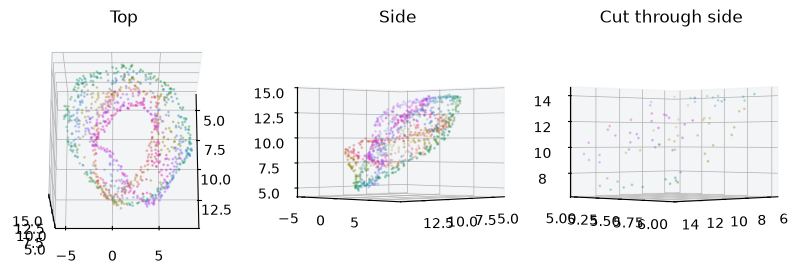

In [115]:
fig, ax = plt.subplots(1, 3, figsize=(10, 6), subplot_kw={"projection": "3d"})

elevs = [70, 0, 0]
azims = [0, 45, 45]

labels = ["Top", "Side", "Cut through side"]

for i in range(3):

    mask = np.ones(len(umap_embedding_sub_3D), dtype=bool)
    if i > 1:
        mask = (umap_embedding_sub_3D[:, 1] > 5) * (umap_embedding_sub_3D[:, 1] < 6)

    ax[i].scatter(
        *umap_embedding_sub_3D[mask].T,
        #c=pca[:len(umap_embedding), 2][mask],
        #c=np.sin(phases[subsample, 0])[mask],
        c=phases[subsample, 1][mask],
        cmap=cmocean.cm.phase,
        s=1,  # marker size
        alpha=0.6
    )
    ax[i].view_init(elev=elevs[i], azim=azims[i])
    ax[i].set_title(labels[i])

In [116]:
# all points

In [117]:
# first some UMAP embeddings for sanity checking. 2D looks as good as it can, 3D looks great
umap_embedding = umap.UMAP(n_components=3, min_dist=0.8).fit_transform(pca[:, :5])
umap_embedding_2d = umap.UMAP(n_components=2, min_dist=0.8).fit_transform(pca[:, :5])

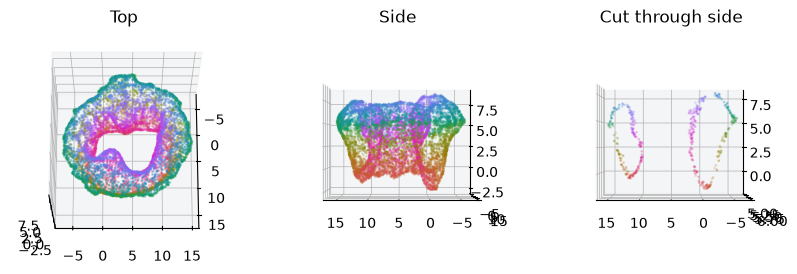

In [118]:
fig, ax = plt.subplots(1, 3, figsize=(10, 6), subplot_kw={"projection": "3d"})

elevs = [70, 0, 0]
azims = [0, 90, 90]

labels = ["Top", "Side", "Cut through side"]

for i in range(3):

    mask = np.ones(len(umap_embedding), dtype=bool)
    if i > 1:
        mask = (umap_embedding[:, 1] >5) * (umap_embedding[:, 1] < 6)

    ax[i].scatter(
        *umap_embedding[mask].T,
        #c=pca[:len(umap_embedding), 2][mask],
        #c=np.sin(phases[:len(umap_embedding), 0])[mask],
        c=cmap(phases[:len(umap_embedding), 1]/(2*np.pi))[mask],
        s=1,          # marker size
        alpha=0.6
    )
    ax[i].view_init(elev=elevs[i], azim=azims[i])
    ax[i].set_title(labels[i])

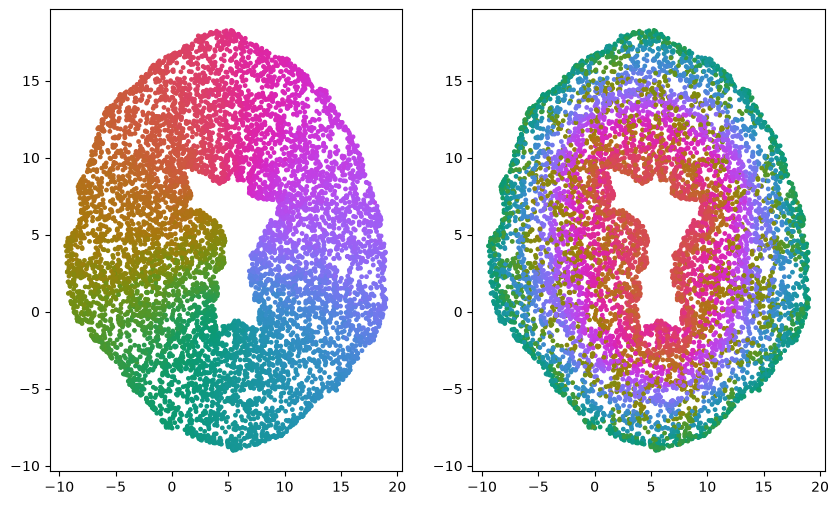

In [119]:
fig, ax = plt.subplots(1, 2, figsize=(10, 6))

ax[0].scatter(umap_embedding_2d[:, 0], umap_embedding_2d[:, 1], c=phases[:, 0], cmap=cmap, s=6)
ax[1].scatter(umap_embedding_2d[:, 0], umap_embedding_2d[:, 1], c=phases[:, 1], cmap=cmap, s=6)

## Full data: geodesic distances, spectral init, MDS with init

Needs the regenerated `phases.npy` (angles in [0, 2*pi), see `data_generation/load_3figures.ipynb`).

Why the runs above fail: raw Euclidean distances are chords, which saturate with angular separation, and the yoda loop is ~1.9x larger in feature space than the bulldog loop, so its residuals dominate the stress and the bulldog direction gets scrambled. Geodesic distances on the full kNN graph fix the metric.

The spectral init is near-perfect on the full data. The disappointing result above came from the 1000-frame subsample, whose kNN graph is much coarser along the bulldog direction (median 15-NN offset ~15 deg vs ~4 deg on the full data), not from the init code. If the spectral init ever looks noisy, note that `eigsh(..., which="SM")` converges poorly for the smallest eigenvalues; `eigsh(L, k, sigma=0, which="LM")` (shift-invert) is the robust variant.

In [120]:
# now MDS

In [121]:
# all-pairs geodesic distances on the full data. apsp_distance_matrix is slow because
# networkx runs a pure-python dijkstra (~100-1000x slower per edge relaxation than C),
# not because APSP is inherently too expensive here.
from scipy.sparse.csgraph import dijkstra

k = 15
A_geo = kneighbors_graph(pca, n_neighbors=k, mode='distance', include_self=False)
A_geo = A_geo.maximum(A_geo.T)  # symmetrize, weights = euclidean edge lengths
G_geo = nx.from_scipy_sparse_array(A_geo)

D_geo, _ = apsp_distance_matrix(G_geo)

assert not np.isinf(D_geo).any(), "kNN graph is disconnected, increase k"
print(D_geo.shape, f"max geodesic: {D_geo.max():.0f}")

(8100, 8100) max geodesic: 60203


In [122]:
spec = find_fundamental_torus_directions(D_geo)
fund = spec["fundamental_directions"]
init_spectral = torus_init_from_eigenpairs(fund[0]["eigenvectors"], fund[1]["eigenvectors"])
print(f"estimated aspect ratio: {spec['aspect_ratio']:.2f}")
report_recovery(init_spectral, phases, "spectral init")

estimated aspect ratio: 1.19
spectral init, axis 0: circ_align yoda 0.980, bulldog 0.055
spectral init, axis 1: circ_align yoda 0.036, bulldog 0.959


Text(0.5, 0.98, 'Spectral layout full dataset')

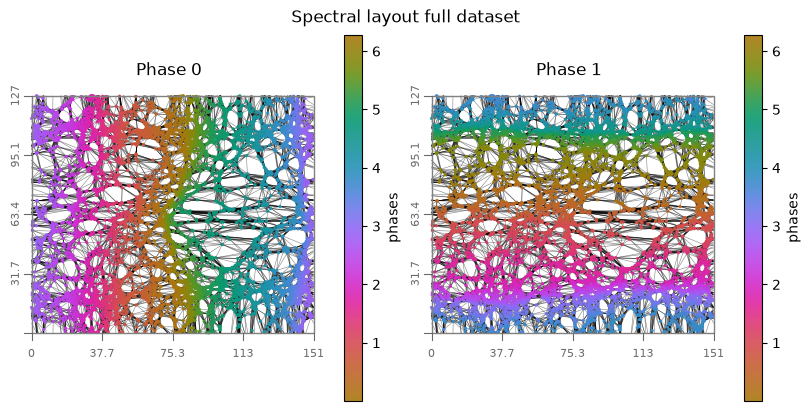

In [123]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4), constrained_layout=True)


colors = [cmap(phase / ( 2*np.pi)) for phase in phases.T]

for i in range(2):
    plot_embedding_with_torus_edges(
        G=G_geo, torus=_torus_geom_from_result(spec), ax=ax[i], s=2, colors=phases[:, i], cmap=cmap, edge_alpha=0.5)
    plt.colorbar(ax[i].collections[-1], ax=ax[i], label="phases")
    ax[i].set_title(f"Phase {i}")
fig.suptitle("Spectral layout full dataset")


SGD from GT init, axis 0: circ_align yoda 0.990, bulldog 0.021
SGD from GT init, axis 1: circ_align yoda 0.001, bulldog 0.881


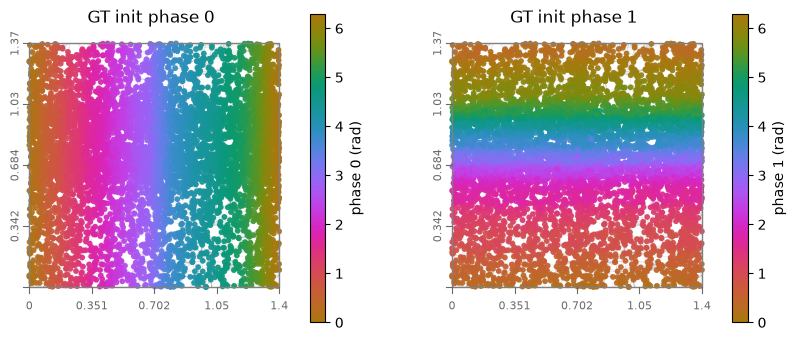

In [124]:
# upper bound for the current objective: SGD from the ground-truth angles.

init_gt = phases / (2 * np.pi)
proj_gt = MDSTorusProjector()
X_gt = proj_gt.fit_transform(D_geo / D_geo.max(), learn_mode='rectangular',
                             r0_init=1.0, r1_init=1.0, init=init_gt, finalize=FINALIZE_MODE)
report_recovery(X_gt, phases, "SGD from GT init")
# expected: ~0.91 (yoda) / ~0.89 (bulldog)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sm = plt.cm.ScalarMappable(norm=plt.Normalize(0, 2 * np.pi), cmap=cmap)
for i, ax in enumerate(axes):
    plot_embedding_with_torus_edges(X=X_gt, G=G_geo, torus=proj_gt, colors=colors[i], ax=ax)
    fig.colorbar(sm, ax=ax, label=f"phase {i} (rad)")
    ax.set_title(f"GT init phase {i}")
plt.show()

SGD from spectral init, axis 0: circ_align yoda 0.990, bulldog 0.021
SGD from spectral init, axis 1: circ_align yoda 0.001, bulldog 0.881


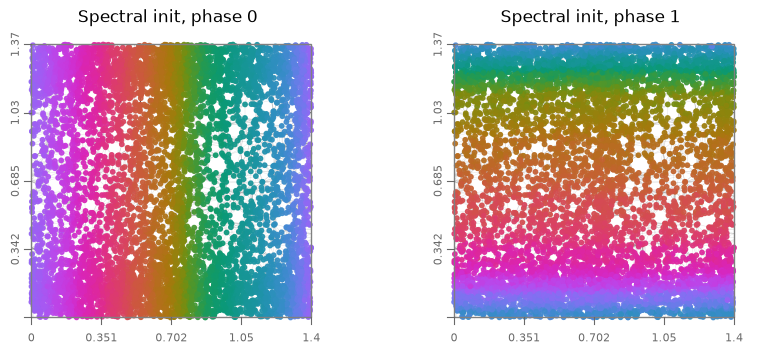

In [125]:
# now start with spectral layout, also works
proj_spec = MDSTorusProjector()
X_spec = proj_spec.fit_transform(D_geo / D_geo.max(), learn_mode='rectangular', init=spec, finalize=FINALIZE_MODE)
report_recovery(X_spec, phases, "SGD from spectral init")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for i, ax in enumerate(axes):
    plot_embedding_with_torus_edges(X=X_spec, G=G_geo, torus=proj_spec, colors=colors[i], ax=ax)
    ax.set_title(f"Spectral init, phase {i}")
plt.show()

SGD from random init, axis 0: circ_align yoda 0.246, bulldog 0.263
SGD from random init, axis 1: circ_align yoda 0.886, bulldog 0.124


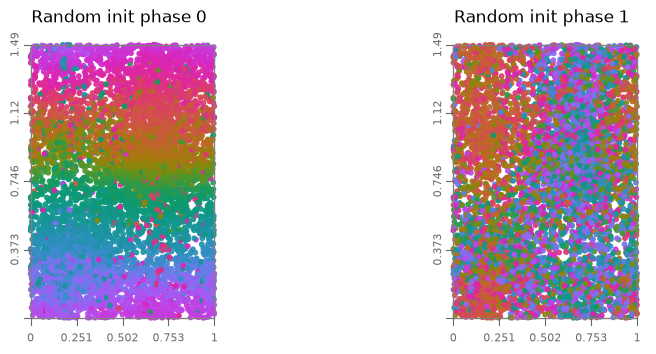

In [134]:
# baseline: SGD from a random init (no spectral/GT warm start), same setup otherwise --> does not work well
proj_rand = MDSTorusProjector()
X_rand = proj_rand.fit_transform(D_geo / D_geo.max(), learn_mode='rectangular',
                                 r0_init=1.0, r1_init=1.0, finalize=FINALIZE_MODE)   # init=None -> random start

report_recovery(X_rand, phases, "SGD from random init")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for i, ax in enumerate(axes):
    plot_embedding_with_torus_edges(X=X_rand, G=None, torus=proj_rand, colors=colors[i], ax=ax)
    ax.set_title(f"Random init phase {i}")
plt.show()

In [127]:
# normalized stress for each embedding (numba-accelerated, rectangular torus).
# scaling per embedding:
#   - spectral init: best-fit alpha on a rectangular flat torus with aspect ratio as in spectral init
#   - GT embedding: best-fit alpha on a square flat torus (r0=r1=1)
#   - optimized runs: each run's own fitted geometry, against the D they trained on
Dn = D_geo / D_geo.max()

s_init, _   = rect_torus_stress(init_spectral, D_geo, r0=1.2, r1=1, alpha=None)
s_gt_emb, _ = rect_torus_stress(init_gt, D_geo, r0=1.0, r1=1.0, alpha=None)
s_gt,   _   = rect_torus_stress(X_gt,   Dn, r0=proj_gt.r0_,   r1=proj_gt.r1_,   alpha=proj_gt.alpha_)
s_spec, _   = rect_torus_stress(X_spec, Dn, r0=proj_spec.r0_, r1=proj_spec.r1_, alpha=proj_spec.alpha_)
s_rand, _   = rect_torus_stress(X_rand, Dn, r0=proj_rand.r0_, r1=proj_rand.r1_, alpha=proj_rand.alpha_)

print(f"spectral init (proposed geom):   stress = {s_init:.4f}")
print(f"GT embedding (best-fit square):  stress = {s_gt_emb:.4f}")
print(f"SGD from GT init (fitted geom):  stress = {s_gt:.4f}")
print(f"SGD from spectral init (fitted): stress = {s_spec:.4f}")
print(f"SGD from random init (fitted):   stress = {s_rand:.4f}")

spectral init (proposed geom):   stress = 0.1343
GT embedding (best-fit square):  stress = 0.1915
SGD from GT init (fitted geom):  stress = 0.0277
SGD from spectral init (fitted): stress = 0.0277
SGD from random init (fitted):   stress = 0.3131


## Subsampled embedding via landmark distances

Embedding a 1000-point subsample works at full-data quality if the graph, geodesics, and spectral init are computed on ALL points and only then restricted to the subsample. Building everything on the subsample alone caps the result at ~0.65-0.87 for two reasons (verified on this data):



In [128]:
D_sub = D_geo[np.ix_(subsample, subsample)]   # landmark geodesics: full-graph distances, subsampled matrix

landmark subsample (no init), axis 0: circ_align yoda 0.030, bulldog 0.881
landmark subsample (no init), axis 1: circ_align yoda 0.990, bulldog 0.029
Stress = 0.0275


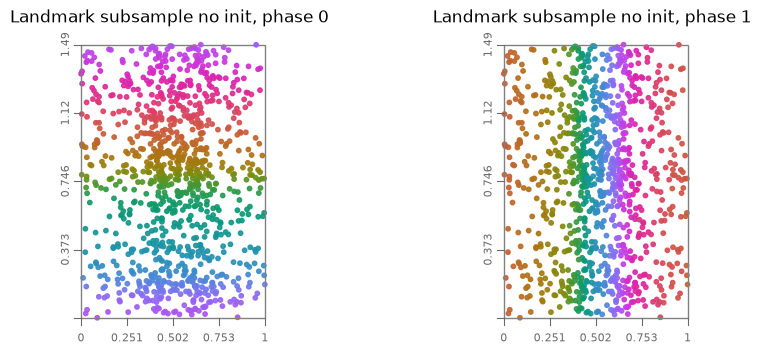

In [129]:
# no init
proj_sub = MDSTorusProjector()
X_sub = proj_sub.fit_transform(D_sub / D_sub.max(), learn_mode='rectangular',
                               r0_init=1.0, r1_init=1.0, init=None, finalize=FINALIZE_MODE)
report_recovery(X_sub, phases[subsample], "landmark subsample (no init)")

s_sub, _   = rect_torus_stress(X_sub, D_sub / D_sub.max(), r0=proj_sub.r0_, r1=proj_sub.r1_, alpha=proj_sub.alpha_)
print(f"Stress = {s_sub:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for i, ax in enumerate(axes):
    plot_embedding_with_torus_edges(X=X_sub, G=None, torus=proj_rand, colors=phases[subsample, i], cmap=cmap, ax=ax)

    ax.set_title(f"Landmark subsample no init, phase {i}")
plt.show()

landmark subsample, axis 0: circ_align yoda 0.980, bulldog 0.053
landmark subsample, axis 1: circ_align yoda 0.033, bulldog 0.960
Stress = 0.1439


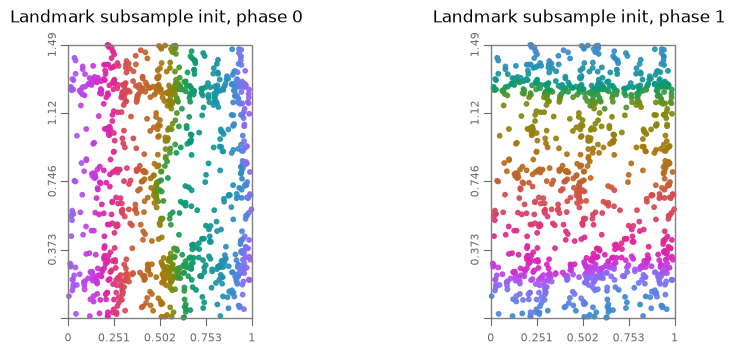

In [130]:
# subsampled spectral init
init_sub = init_spectral[subsample]     # full-data spectral init, restricted to the subsample

report_recovery(init_sub, phases[subsample], "landmark subsample")
s_sub_init_no_train, _   = rect_torus_stress(init_sub, D_sub / D_sub.max(), r0=proj_sub.r0_, r1=proj_sub.r1_, alpha=proj_sub.alpha_)
print(f"Stress = {s_sub_init_no_train:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for i, ax in enumerate(axes):
    plot_embedding_with_torus_edges(X=init_sub, G=None, torus=proj_rand, colors=phases[subsample, i], cmap=cmap, ax=ax)
    ax.set_title(f"Landmark subsample init, phase {i}")
plt.show()

landmark subsample, axis 0: circ_align yoda 0.990, bulldog 0.029
landmark subsample, axis 1: circ_align yoda 0.030, bulldog 0.881
Stress = 0.0275


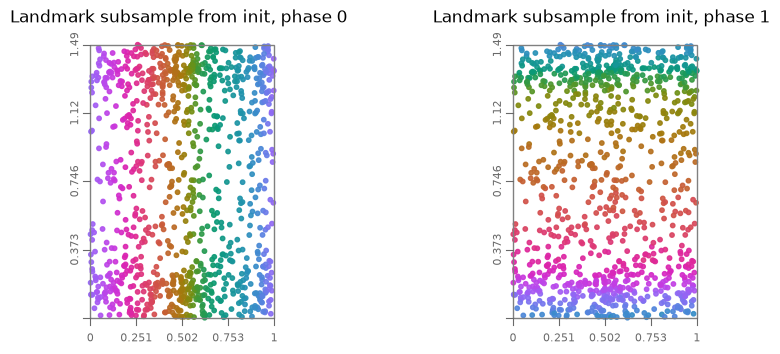

In [131]:
# now train from subsampled spectral init --> sometimes weird checkerboard pattern. Weakly visible also in subsampled init.

proj_sub = MDSTorusProjector()
X_sub_init = proj_sub.fit_transform(D_sub / D_sub.max(), learn_mode='rectangular',
                               r0_init=1.2, r1_init=1.0, init=init_sub, finalize=FINALIZE_MODE)
report_recovery(X_sub_init, phases[subsample], "landmark subsample")
s_sub_init, _   = rect_torus_stress(X_sub_init, D_sub / D_sub.max(), r0=proj_sub.r0_, r1=proj_sub.r1_, alpha=proj_sub.alpha_)
print(f"Stress = {s_sub_init:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for i, ax in enumerate(axes):
    plot_embedding_with_torus_edges(X=X_sub_init, G=None, torus=proj_rand, colors=phases[subsample, i], cmap=cmap, ax=ax)
    ax.set_title(f"Landmark subsample from init, phase {i}")
plt.show()